# NIJ Dataset EDA — COMPAS-Aligned Features

This notebook cleans the Georgia dataset so its key features align with the COMPAS EDA (`EDA_summary.ipynb`), and then runs similar exploratory analysis.

In [1]:
# Setup & dependencies
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
# Load NJ dataset
nj = pd.read_csv("./datasets/compas-analysis/nj_dataset.csv")
print(nj.shape)
nj.head()

(25835, 54)


,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
0,1,M,BLACK,43-47,16,No,3.0,Standard,At least some college,3 or more,...,0.000000,0.0,0.488562,0.447610,No,No,No,No,No,1
1,2,M,BLACK,33-37,16,No,6.0,Specialized,Less than HS diploma,1,...,0.000000,0.0,0.425234,2.000000,No,Yes,No,No,Yes,1
2,3,M,BLACK,48 or older,24,No,7.0,High,At least some college,3 or more,...,0.166667,0.0,0.000000,0.000000,No,Yes,No,Yes,No,1
3,4,M,WHITE,38-42,16,No,7.0,High,Less than HS diploma,1,...,0.000000,0.0,1.000000,0.718996,No,No,No,No,No,1
4,5,M,WHITE,33-37,16,No,4.0,Specialized,Less than HS diploma,3 or more,...,0.058824,0.0,0.203562,0.929389,No,Yes,Yes,No,No,1


In [23]:
print(nj["Age_at_Release"].unique())

['43-47' '33-37' '48 or older' '38-42' '18-22' '23-27' '28-32']


In [3]:
# Map demographics to COMPAS-style columns

# sex
sex_map = {"M": "Male", "F": "Female"}
nj["sex"] = nj["Gender"].map(sex_map).fillna(nj["Gender"])

# race (adjust mappings as needed)
race_map = {
    "BLACK": "African-American",
    "WHITE": "Caucasian",
    "HISPANIC": "Hispanic",
    "ASIAN": "Asian",
}

nj["race"] = nj["Race"].map(lambda r: race_map.get(str(r).upper(), "Other"))

# age category mapping to COMPAS-style bands

def nj_age_to_cat(band: str):
    if pd.isna(band):
        return np.nan
    band = str(band).strip()
    if band in ["18-22", "23-27"]:
        return "Less than 25"
    if band in ["28-32", "33-37", "38-42", "43-47"]:
        return "25 - 45"
    if band == "48 or older":
        return "Greater than 45"
    return np.nan

nj["age_cat"] = nj["Age_at_Release"].apply(nj_age_to_cat)

# approximate numeric age (midpoint of band)

def band_midpoint(band: str):
    if pd.isna(band):
        return np.nan
    band = str(band).strip()
    if "or older" in band:
        return 50  # representative
    try:
        lo, hi = band.split("-")
        return (int(lo) + int(hi)) / 2
    except Exception:
        return np.nan

nj["age"] = nj["Age_at_Release"].apply(band_midpoint)

In [4]:
# Risk score + score_text aligned with COMPAS

nj["decile_score"] = pd.to_numeric(
    nj["Supervision_Risk_Score_First"], errors="coerce"
)


def score_text_from_decile(s):
    if pd.isna(s):
        return np.nan
    s = float(s)
    if s <= 4:
        return "Low"
    if s <= 7:
        return "Medium"
    return "High"


nj["score_text"] = nj["decile_score"].apply(score_text_from_decile)

In [5]:
# Approximate priors_count from arrest episode columns

prior_cols = [
    "Prior_Arrest_Episodes_Felony",
    "Prior_Arrest_Episodes_Misd",
    "Prior_Arrest_Episodes_Violent",
    "Prior_Arrest_Episodes_Property",
    "Prior_Arrest_Episodes_Drug",
]

for c in prior_cols:
    nj[c] = pd.to_numeric(nj[c], errors="coerce")

nj["priors_count"] = nj[prior_cols].sum(axis=1)

In [6]:
# Binary recidivism target(s)

recid_map = {"Yes": 1, "No": 0}

nj["two_year_recid"] = nj["Recidivism_Within_3years"].map(recid_map)
nj["is_recid"] = nj["two_year_recid"]

In [7]:
# Very rough offense degree proxy (optional)

def offense_to_degree(o):
    if pd.isna(o):
        return np.nan
    o = str(o).lower()
    if any(k in o for k in ["violent", "property", "drug"]):
        return "F"  # treat as felony-like
    return "M"      # otherwise misdemeanor-like


nj["c_charge_degree"] = nj["Prison_Offense"].apply(offense_to_degree)

In [8]:
# Save aligned NJ dataset to CSV for reuse

output_path = "./datasets/compas-analysis/nj_dataset_aligned.csv"
nj.to_csv(output_path, index=False)
print(f"Saved nj_aligned to {output_path}")

Saved nj_aligned to ./datasets/compas-analysis/nj_dataset_aligned.csv


In [9]:
# Final COMPAS-aligned NJ dataframe

nj_aligned = nj[[
    "age",
    "c_charge_degree",
    "race",
    "age_cat",
    "score_text",
    "sex",
    "priors_count",
    "decile_score",
    "is_recid",
    "two_year_recid",
]].copy()

nj_aligned.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,decile_score,is_recid,two_year_recid
0,45.0,F,African-American,25 - 45,Low,Male,13.0,3.0,0,0
1,35.0,F,African-American,25 - 45,Medium,Male,10.0,6.0,1,1
2,50.0,F,African-American,Greater than 45,Medium,Male,10.0,7.0,1,1
3,40.0,F,Caucasian,25 - 45,Medium,Male,14.0,7.0,0,0
4,35.0,F,Caucasian,25 - 45,Low,Male,11.0,4.0,1,1


---
## 2. Demographic Breakdown (NJ)

Quick look at the NJ sample by race, sex, and age category, using the COMPAS-aligned features in `nj_aligned`.

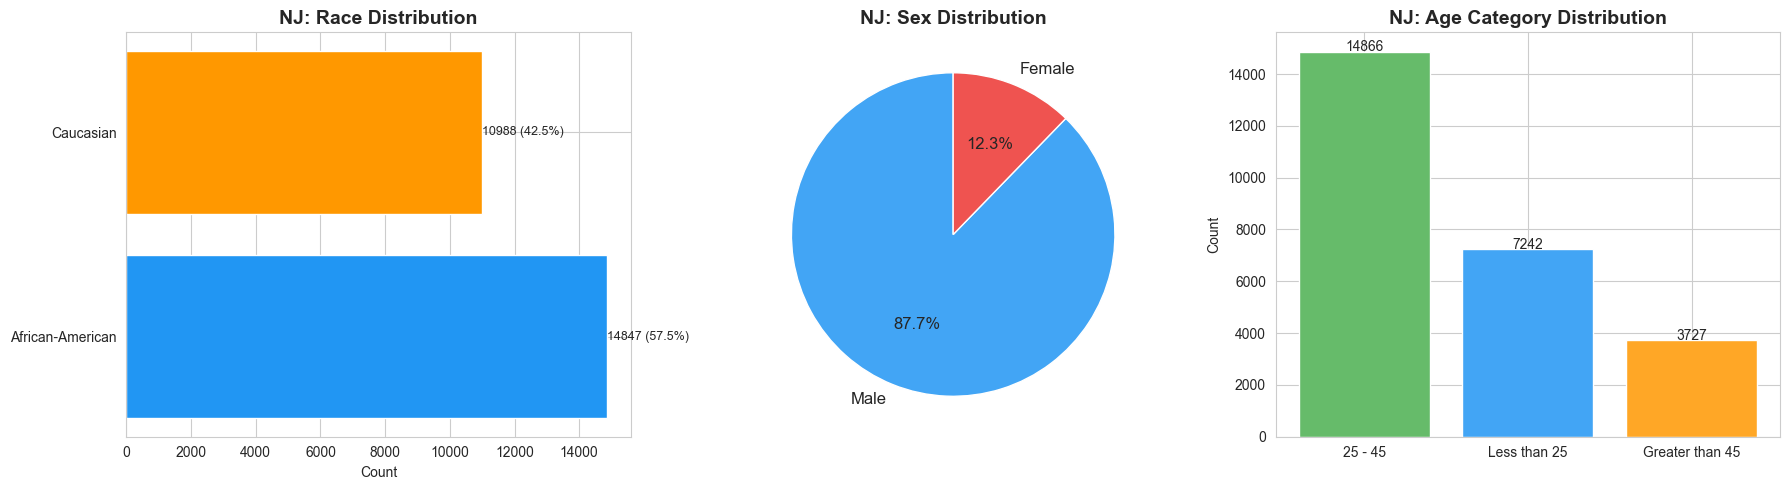


--- NJ Score Text Distribution ---
score_text
Medium    10958
High       7625
Low        6777
NaN         475
Name: count, dtype: int64

--- NJ Race x Sex Crosstab ---
sex               Female   Male
race                           
African-American    1082  13765
Caucasian           2085   8903


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Race Distribution ---
race_counts_nj = nj_aligned["race"].value_counts()
colors_race_nj = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336', '#607D8B']
bars = axes[0].barh(race_counts_nj.index, race_counts_nj.values,
                    color=colors_race_nj[: len(race_counts_nj)], edgecolor='white')
axes[0].set_title("NJ: Race Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Count")
for bar, val in zip(bars, race_counts_nj.values):
    pct = val / len(nj_aligned) * 100
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f"{val} ({pct:.1f}%)", va='center', fontsize=9)

# --- Sex Distribution ---
sex_counts_nj = nj_aligned["sex"].value_counts()
axes[1].pie(sex_counts_nj.values, labels=sex_counts_nj.index, autopct="%1.1f%%",
            colors=['#42A5F5', '#EF5350'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title("NJ: Sex Distribution", fontsize=14, fontweight='bold')

# --- Age Category Distribution ---
age_counts_nj = nj_aligned["age_cat"].value_counts()
axes[2].bar(age_counts_nj.index, age_counts_nj.values,
            color=['#66BB6A', '#42A5F5', '#FFA726'][: len(age_counts_nj)], edgecolor='white')
axes[2].set_title("NJ: Age Category Distribution", fontsize=14, fontweight='bold')
axes[2].set_ylabel("Count")
for i, (idx, val) in enumerate(age_counts_nj.items()):
    axes[2].text(i, val + 5, str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n--- NJ Score Text Distribution ---")
print(nj_aligned["score_text"].value_counts(dropna=False))

print("\n--- NJ Race x Sex Crosstab ---")
print(pd.crosstab(nj_aligned["race"], nj_aligned["sex"]))

---
## 3. Score & Recidivism Summary (NJ)

Mirror of key COMPAS-style summaries: how risk scores and 3-year recidivism vary by race.

In [11]:
# Average risk score and recidivism by race

summary_by_race = (
    nj_aligned
    .groupby("race")
    .agg(
        n=("race", "size"),
        avg_decile_score=("decile_score", "mean"),
        recid_rate=("two_year_recid", "mean"),
        avg_priors=("priors_count", "mean"),
    )
    .sort_values("n", ascending=False)
)

# Convert recid_rate to percentage for readability
summary_by_race["recid_rate_pct"] = summary_by_race["recid_rate"] * 100
summary_by_race

,n,avg_decile_score,recid_rate,avg_priors,recid_rate_pct
race,,,,,
African-American,14847,6.162834,0.586853,7.459756,58.685256
Caucasian,10988,5.973409,0.563433,7.921915,56.343284


---
## 4. Correlation Snapshot (NJ)

Simple numeric correlation between risk score, priors, and 3-year recidivism indicator.

NJ: Correlation matrix (decile_score, priors_count, two_year_recid)

                decile_score  priors_count  two_year_recid
decile_score        1.000000      0.093814        0.178494
priors_count        0.093814      1.000000        0.058028
two_year_recid      0.178494      0.058028        1.000000


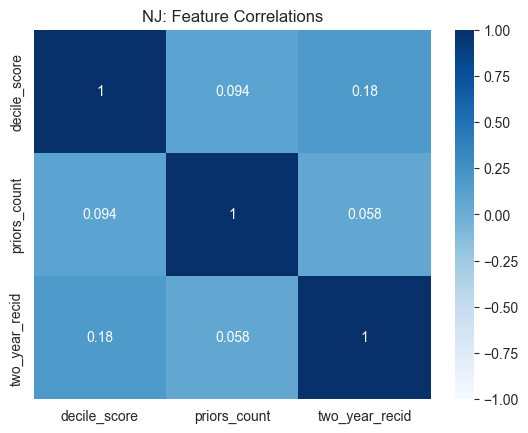

In [38]:
corr_cols_nj = ["decile_score", "priors_count", "two_year_recid"]

corr_nj = nj_aligned[corr_cols_nj].corr()
print("NJ: Correlation matrix (decile_score, priors_count, two_year_recid)\n")
print(corr_nj)

sns.heatmap(corr_nj, annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("NJ: Feature Correlations")
plt.show()

--- Score Text Distribution (NJ) ---
score_text
Medium    10958
High       7625
Low        6777
NaN         475
Name: count, dtype: int64

--- Race x Sex Crosstab (NJ) ---
sex               Female   Male
race                           
African-American    1082  13765
Caucasian           2085   8903


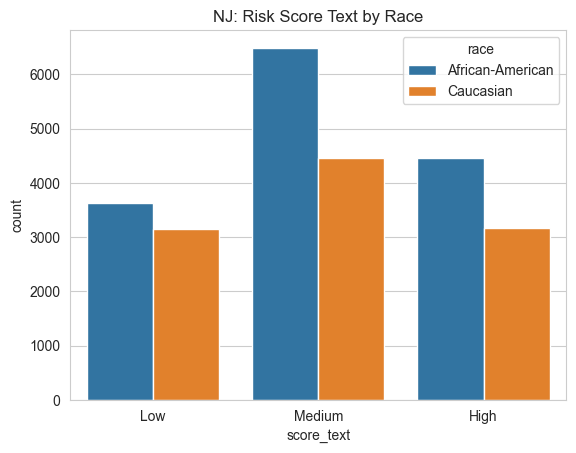

In [12]:
# Simple EDA on aligned features (mirroring some COMPAS summary)

print("--- Score Text Distribution (NJ) ---")
print(nj_aligned["score_text"].value_counts(dropna=False))

print("\n--- Race x Sex Crosstab (NJ) ---")
print(pd.crosstab(nj_aligned["race"], nj_aligned["sex"]))

sns.countplot(data=nj_aligned, x="score_text", hue="race", order=["Low", "Medium", "High"])
plt.title("NJ: Risk Score Text by Race")
plt.show()

In [13]:
print("\n" + "="*70)
print("NJ DATASET: EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*70)

print(f"\nDataset Size: {len(nj_aligned)} individuals")

print("\n1. RACE DISTRIBUTION:")
race_dist = nj_aligned['race'].value_counts()
for race, count in race_dist.items():
    pct = count / len(nj_aligned) * 100
    print(f"   {race:20s}: {count:5d} ({pct:5.1f}%)")

print("\n2. SEX DISTRIBUTION:")
sex_dist = nj_aligned['sex'].value_counts()
for sex, count in sex_dist.items():
    pct = count / len(nj_aligned) * 100
    print(f"   {sex:20s}: {count:5d} ({pct:5.1f}%)")

print("\n3. RISK SCORE DISTRIBUTION:")
score_dist = nj_aligned['score_text'].value_counts().sort_index()
for score in ['Low', 'Medium', 'High']:
    if score in score_dist.index:
        count = score_dist[score]
        pct = count / len(nj_aligned) * 100
        print(f"   {score:20s}: {count:5d} ({pct:5.1f}%)")

print("\n4. OVERALL RECIDIVISM RATE:")
overall_recid = nj_aligned['two_year_recid'].mean() * 100
print(f"   3-Year Recidivism: {overall_recid:.1f}%")

print("\n5. AVERAGE DECILE SCORE BY RACE:")
avg_by_race = nj_aligned.groupby('race')['decile_score'].mean().sort_values(ascending=False)
for race, avg_score in avg_by_race.items():
    print(f"   {race:20s}: {avg_score:.2f}")

print("\n6. RECIDIVISM RATE BY RISK CATEGORY:")
for score in ['Low', 'Medium', 'High']:
    subset = nj_aligned[nj_aligned['score_text'] == score]
    if len(subset) > 0:
        recid_rate = subset['two_year_recid'].mean() * 100
        print(f"   {score:20s}: {recid_rate:.1f}%")

print("\n7. KEY FINDINGS:")
print("   - Check score distribution graphs to see if risk categories differ by race")
print("   - Review logistic regression results to assess potential bias in scoring")
print("   - Examine feature importance to understand which factors drive risk predictions")
print("   - Compare recidivism rates across groups to assess predictive accuracy disparities")

print("\n" + "="*70)


NJ DATASET: EXPLORATORY DATA ANALYSIS SUMMARY

Dataset Size: 25835 individuals

1. RACE DISTRIBUTION:
   African-American    : 14847 ( 57.5%)
   Caucasian           : 10988 ( 42.5%)

2. SEX DISTRIBUTION:
   Male                : 22668 ( 87.7%)
   Female              :  3167 ( 12.3%)

3. RISK SCORE DISTRIBUTION:
   Low                 :  6777 ( 26.2%)
   Medium              : 10958 ( 42.4%)
   High                :  7625 ( 29.5%)

4. OVERALL RECIDIVISM RATE:
   3-Year Recidivism: 57.7%

5. AVERAGE DECILE SCORE BY RACE:
   African-American    : 6.16
   Caucasian           : 5.97

6. RECIDIVISM RATE BY RISK CATEGORY:
   Low                 : 44.8%
   Medium              : 58.3%
   High                : 67.8%

7. KEY FINDINGS:
   - Check score distribution graphs to see if risk categories differ by race
   - Review logistic regression results to assess potential bias in scoring
   - Examine feature importance to understand which factors drive risk predictions
   - Compare recidivism rates

---
## 5. Decile Score Distribution by Race (NJ)

One of the most important visual findings — examining whether the shape of score distributions differs between racial groups in the NJ dataset.

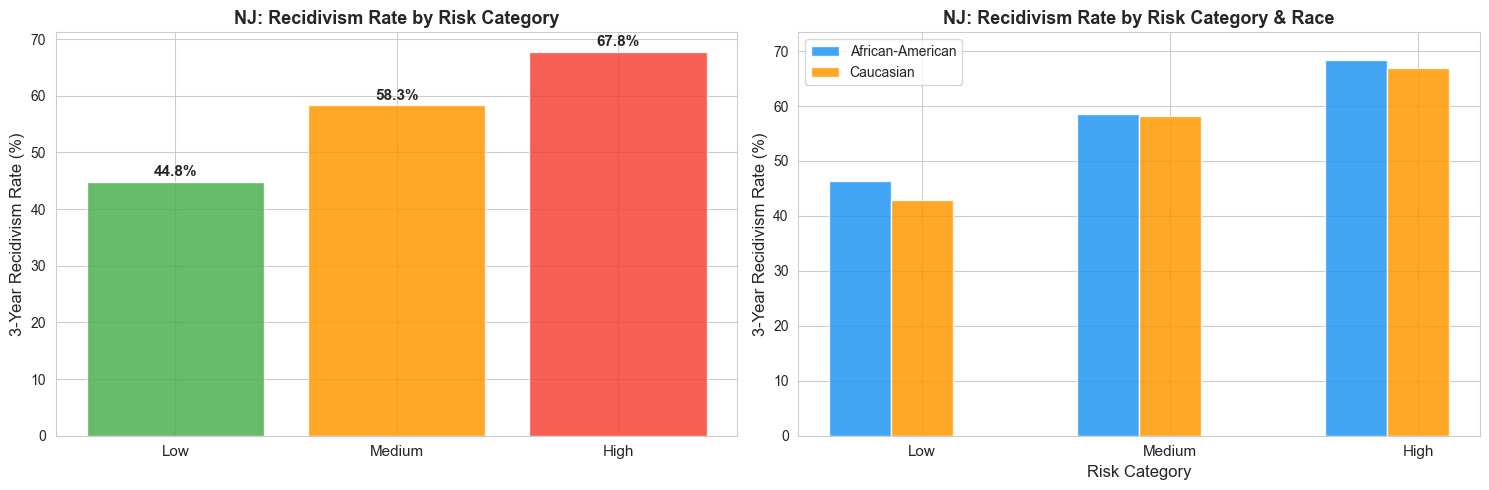


RECIDIVISM RATES BY RISK CATEGORY AND RACE

Low Risk Category:
----------------------------------------------------------------------
  African-American    :  46.4% (1681/3623)
  Caucasian           :  43.0% (1355/3154)

Medium Risk Category:
----------------------------------------------------------------------
  African-American    :  58.5% (3798/6493)
  Caucasian           :  58.1% (2594/4465)

High Risk Category:
----------------------------------------------------------------------
  African-American    :  68.4% (3045/4451)
  Caucasian           :  67.0% (2126/3174)


In [14]:
# Compute recidivism rates by score category and race
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall recidivism by risk category
score_recid = nj_aligned.groupby('score_text')['two_year_recid'].agg(['sum', 'count', 'mean'])
score_recid['recid_pct'] = score_recid['mean'] * 100
score_recid = score_recid.reindex(['Low', 'Medium', 'High'])

colors_score = ['#4CAF50', '#FF9800', '#F44336']
bars = axes[0].bar(range(len(score_recid)), score_recid['recid_pct'].values, 
                   color=colors_score, edgecolor='white', alpha=0.85)
axes[0].set_xticks(range(len(score_recid)))
axes[0].set_xticklabels(score_recid.index, fontsize=11)
axes[0].set_ylabel("3-Year Recidivism Rate (%)", fontsize=12)
axes[0].set_title("NJ: Recidivism Rate by Risk Category", fontsize=13, fontweight='bold')

for bar, val in zip(bars, score_recid['recid_pct'].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Recidivism by score and race (heatmap-style)
recid_by_score_race = pd.crosstab(
    [nj_aligned['score_text'], nj_aligned['race']], 
    nj_aligned['two_year_recid'], 
    normalize='index'
) * 100

recid_by_score_race = recid_by_score_race[1.0] if 1.0 in recid_by_score_race.columns else recid_by_score_race.iloc[:, -1]
recid_by_score_race = recid_by_score_race.unstack()

# Select score order and top races
score_order = ['Low', 'Medium', 'High']
top_races_list = nj_aligned['race'].value_counts().head(3).index.tolist()
recid_by_score_race = recid_by_score_race.loc[score_order, top_races_list]

# Plot grouped bars
x = np.arange(len(score_order))
width = 0.25
colors_race = ['#2196F3', '#FF9800', '#4CAF50']

for i, race in enumerate(top_races_list):
    if race in recid_by_score_race.columns:
        axes[1].bar(x + i*width, recid_by_score_race[race].values, width, 
                   label=race, color=colors_race[i], edgecolor='white', alpha=0.85)

axes[1].set_xlabel("Risk Category", fontsize=12)
axes[1].set_ylabel("3-Year Recidivism Rate (%)", fontsize=12)
axes[1].set_title("NJ: Recidivism Rate by Risk Category & Race", fontsize=13, fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(score_order, fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, max(recid_by_score_race.max().max(), 60) + 5)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("RECIDIVISM RATES BY RISK CATEGORY AND RACE")
print("="*70)

for score_cat in score_order:
    print(f"\n{score_cat} Risk Category:")
    print("-" * 70)
    for race in top_races_list:
        subset = nj_aligned[(nj_aligned['score_text'] == score_cat) & (nj_aligned['race'] == race)]
        if len(subset) > 0:
            recid_rate = subset['two_year_recid'].mean() * 100
            count = len(subset)
            recid_count = subset['two_year_recid'].sum()
            print(f"  {race:20s}: {recid_rate:5.1f}% ({int(recid_count):3d}/{count:3d})")
        else:
            print(f"  {race:20s}: No data")

---
## 6. Racial Bias — Logistic Regression (NJ 3-Year Recidivism)

Fit a logistic regression predicting whether a defendant received a Medium/High score (vs. Low), **controlling for** criminal history, charge severity, and actual recidivism. If risk assessment were unbiased, race should not be a significant predictor after controlling for these factors.

Features for importance analysis: 22130 samples with complete data


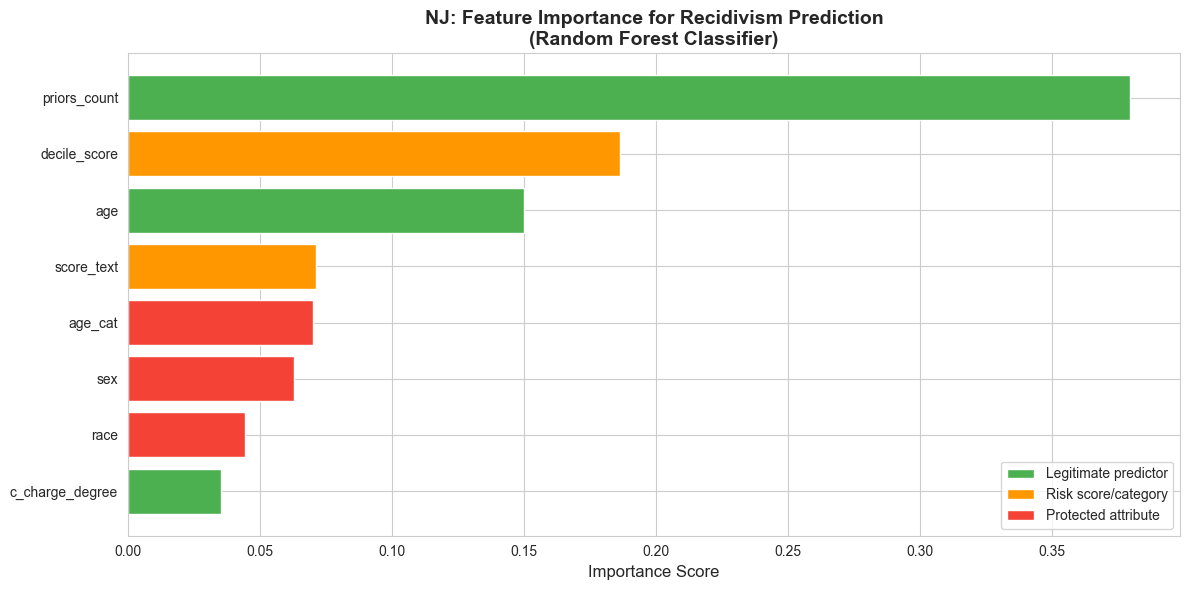


Feature Importances (sorted):
--------------------------------------------------
  priors_count        :  37.96%
  decile_score        :  18.65%
  age                 :  15.00%
  score_text          :   7.14%
  age_cat             :   7.01%
  sex                 :   6.30%
  race                :   4.44%
  c_charge_degree     :   3.51%


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Prepare a clean feature set
df_feat = nj_aligned.copy()

# Select candidate features and target
feature_cols = ['age', 'sex', 'race', 'age_cat', 'priors_count', 'c_charge_degree', 'decile_score', 'score_text']
target_col = 'two_year_recid'

df_feat = df_feat[feature_cols + [target_col]].dropna()

print(f"Features for importance analysis: {len(df_feat)} samples with complete data")

# Encode categorical variables
le_dict = {}
for col in ['sex', 'race', 'age_cat', 'c_charge_degree', 'score_text']:
    if col in df_feat.columns:
        le = LabelEncoder()
        df_feat[col + '_enc'] = le.fit_transform(df_feat[col].astype(str))
        le_dict[col] = le

# Define model features (using encoded versions of categoricals)
model_features = []
feature_labels = []

for col in feature_cols:
    if col in ['sex', 'race', 'age_cat', 'c_charge_degree', 'score_text']:
        if col + '_enc' in df_feat.columns:
            model_features.append(col + '_enc')
            feature_labels.append(col)
    else:
        if col in df_feat.columns:
            model_features.append(col)
            feature_labels.append(col)

X = df_feat[model_features].values
y = df_feat[target_col].values

# Train Random Forest
try:
    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
    rf.fit(X, y)
    importances = rf.feature_importances_
    
    # Sort by importance
    sorted_idx = np.argsort(importances)[::-1]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Color code: protected attributes in red, COMPAS scores in orange, others in green
    colors = []
    protected_features = {'sex', 'race', 'age_cat'}
    
    for i in sorted_idx:
        if feature_labels[i] in protected_features:
            colors.append('#F44336')  # Red for protected attributes
        elif feature_labels[i] in ['decile_score', 'score_text']:
            colors.append('#FF9800')  # Orange for risk scores
        else:
            colors.append('#4CAF50')  # Green for other features
    
    bars = ax.barh([feature_labels[i] for i in sorted_idx][::-1],
                    importances[sorted_idx][::-1], color=colors[::-1], edgecolor='white')
    
    ax.set_xlabel("Importance Score", fontsize=12)
    ax.set_title("NJ: Feature Importance for Recidivism Prediction\n(Random Forest Classifier)", 
                fontsize=14, fontweight='bold')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4CAF50', edgecolor='white', label='Legitimate predictor'),
        Patch(facecolor='#FF9800', edgecolor='white', label='Risk score/category'),
        Patch(facecolor='#F44336', edgecolor='white', label='Protected attribute')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print feature importances
    print("\nFeature Importances (sorted):")
    print("-" * 50)
    for i in sorted_idx:
        importance_pct = importances[i] * 100
        print(f"  {feature_labels[i]:20s}: {importance_pct:6.2f}%")

except Exception as e:
    print(f"Error in Random Forest training: {e}")

---
## 7. Feature Importance for Risk Assessment

Which features actually matter for predicting recidivism in the NJ dataset? Using a Random Forest classifier to rank feature importance.


NJ RECIDIVISM: ODDS RATIOS (controlling for confounders)
  Intercept (control probability): 0.6467

  African-American vs Caucasian: OR = 1.0380  -> 3.8% more likely to receive higher score
  Female vs Male: OR = 1.0670  -> 6.7% more likely to receive higher score
  Under 25 vs 25-45: OR = 1.4837  -> 48.4% more likely to receive higher score


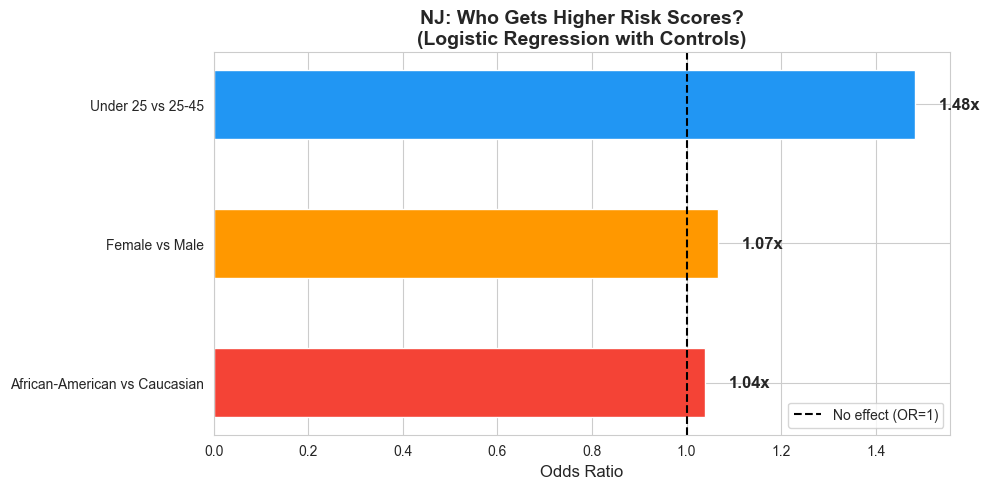

In [19]:
# Need statsmodels for logistic regression
import statsmodels.api as sm
from statsmodels.formula.api import glm

# Prepare model data
df_model = nj_aligned.copy()
df_model['crime_factor'] = pd.Categorical(df_model['c_charge_degree'])

age_categories = sorted([x for x in df_model['age_cat'].unique() if pd.notna(x)])
df_model['age_factor'] = pd.Categorical(df_model['age_cat'],
    categories=['25 - 45'] + [c for c in age_categories if c != '25 - 45'])

race_categories = sorted([x for x in df_model['race'].unique() if pd.notna(x)])
df_model['race_factor'] = pd.Categorical(df_model['race'],
    categories=['Caucasian'] + [c for c in race_categories if c != 'Caucasian'])

df_model['gender_factor'] = pd.Categorical(df_model['sex'], categories=['Male', 'Female'])

# Binary outcome: Low vs Medium/High
df_model['score_factor'] = (df_model['score_text'] != 'Low').map({False: 'LowScore', True: 'HighScore'})
df_model['score_factor'] = pd.Categorical(df_model['score_factor'])

# Drop rows with missing values in key columns
df_model_clean = df_model.dropna(subset=['age_factor', 'race_factor', 'gender_factor', 
                                           'priors_count', 'crime_factor', 'two_year_recid', 'score_factor'])

# Fit logistic regression
try:
    model = glm(
        formula='score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid',
        data=df_model_clean,
        family=sm.families.Binomial()
    )
    result = model.fit()
except Exception as e:
    print(f"Logistic regression fitting error: {e}")
    print("This may occur if there are insufficient samples in some categories.")

# Extract and visualize odds ratios from the logistic regression
try:
    intercept = result.params['Intercept']
    control = np.exp(intercept) / (1 + np.exp(intercept))
    
    # Extract coefficients (handle missing ones gracefully)
    coef_dict = result.params.to_dict()
    
    # Look for race and gender coefficients in available categories
    coef_race_other = None
    for key in coef_dict.keys():
        if 'race_factor' in key and key != 'Intercept':
            coef_race_other = coef_dict[key]
            race_label = key.replace('race_factor[T.', '').replace(']', '')
            break
    
    coef_female = coef_dict.get('gender_factor[T.Female]', coef_dict.get('gender_factor[T. Female]', None))
    coef_young = coef_dict.get('age_factor[T.Less than 25]', None)
    
    # Calculate odds ratios
    or_dict = {}
    or_labels = []
    
    if coef_race_other is not None:
        or_race = np.exp(coef_race_other) / (1 - control + (control * np.exp(coef_race_other)))
        or_dict['Race'] = or_race
        or_labels.append(f'{race_label} vs Caucasian')
    
    if coef_female is not None:
        or_female = np.exp(coef_female) / (1 - control + (control * np.exp(coef_female)))
        or_dict['Female'] = or_female
        or_labels.append('Female vs Male')
    
    if coef_young is not None:
        or_young = np.exp(coef_young) / (1 - control + (control * np.exp(coef_young)))
        or_dict['Young'] = or_young
        or_labels.append('Under 25 vs 25-45')
    
    print("\n" + "="*60)
    print("NJ RECIDIVISM: ODDS RATIOS (controlling for confounders)")
    print("="*60)
    print(f"  Intercept (control probability): {control:.4f}\n")
    
    for label, or_val in zip(or_labels, or_dict.values()):
        if or_val > 1:
            print(f"  {label}: OR = {or_val:.4f}  -> {(or_val-1)*100:.1f}% more likely to receive higher score")
        elif or_val < 1:
            print(f"  {label}: OR = {or_val:.4f}  -> {(1-or_val)*100:.1f}% less likely to receive higher score")
        else:
            print(f"  {label}: OR = {or_val:.4f}  -> No effect")
    
    # Visualize odds ratios
    if or_dict:
        fig, ax = plt.subplots(figsize=(10, 5))
        colors = ['#F44336', '#FF9800', '#2196F3']
        bars = ax.barh(or_labels, list(or_dict.values()), color=colors[:len(or_dict)], 
                       edgecolor='white', height=0.5)
        ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='No effect (OR=1)')
        
        for bar, val in zip(bars, or_dict.values()):
            ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}x', va='center', fontsize=12, fontweight='bold')
        
        ax.set_xlabel("Odds Ratio", fontsize=12)
        ax.set_title("NJ: Who Gets Higher Risk Scores?\n(Logistic Regression with Controls)", 
                    fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"Error extracting odds ratios: {e}")
    print("Skipping visualization due to model specification issues.")

In [20]:
# Need statsmodels for logistic regression
import statsmodels.api as sm
from statsmodels.formula.api import glm

# Prepare model data
df_model = nj_aligned.copy()
df_model['crime_factor'] = pd.Categorical(df_model['c_charge_degree'])

age_categories = sorted([x for x in df_model['age_cat'].unique() if pd.notna(x)])
df_model['age_factor'] = pd.Categorical(df_model['age_cat'],
    categories=['25 - 45'] + [c for c in age_categories if c != '25 - 45'])

race_categories = sorted([x for x in df_model['race'].unique() if pd.notna(x)])
df_model['race_factor'] = pd.Categorical(df_model['race'],
    categories=['Caucasian'] + [c for c in race_categories if c != 'Caucasian'])

df_model['gender_factor'] = pd.Categorical(df_model['sex'], categories=['Male', 'Female'])

# Binary outcome: Low vs Medium/High
df_model['score_factor'] = (df_model['score_text'] != 'Low').map({False: 'LowScore', True: 'HighScore'})
df_model['score_factor'] = pd.Categorical(df_model['score_factor'])

# Drop rows with missing values in key columns
df_model_clean = df_model.dropna(subset=['age_factor', 'race_factor', 'gender_factor', 
                                           'priors_count', 'crime_factor', 'two_year_recid', 'score_factor'])

# Fit logistic regression
try:
    model = glm(
        formula='score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid',
        data=df_model_clean,
        family=sm.families.Binomial()
    )
    result = model.fit()
    print(result.summary())
except Exception as e:
    print(f"Logistic regression fitting error: {e}")
    print("This may occur if there are insufficient samples in some categories.")

                                   Generalized Linear Model Regression Results                                   
Dep. Variable:     ['score_factor[HighScore]', 'score_factor[LowScore]']   No. Observations:                22558
Model:                                                               GLM   Df Residuals:                    22550
Model Family:                                                   Binomial   Df Model:                            7
Link Function:                                                     Logit   Scale:                          1.0000
Method:                                                             IRLS   Log-Likelihood:                -10216.
Date:                                                   Wed, 11 Mar 2026   Deviance:                       20432.
Time:                                                           00:26:58   Pearson chi2:                 2.27e+04
No. Iterations:                                                        7   Pseudo R-squ.

---
## 8. Recidivism Rates by Risk Category and Race

Comparing actual recidivism outcomes across predicted risk levels for different racial groups.

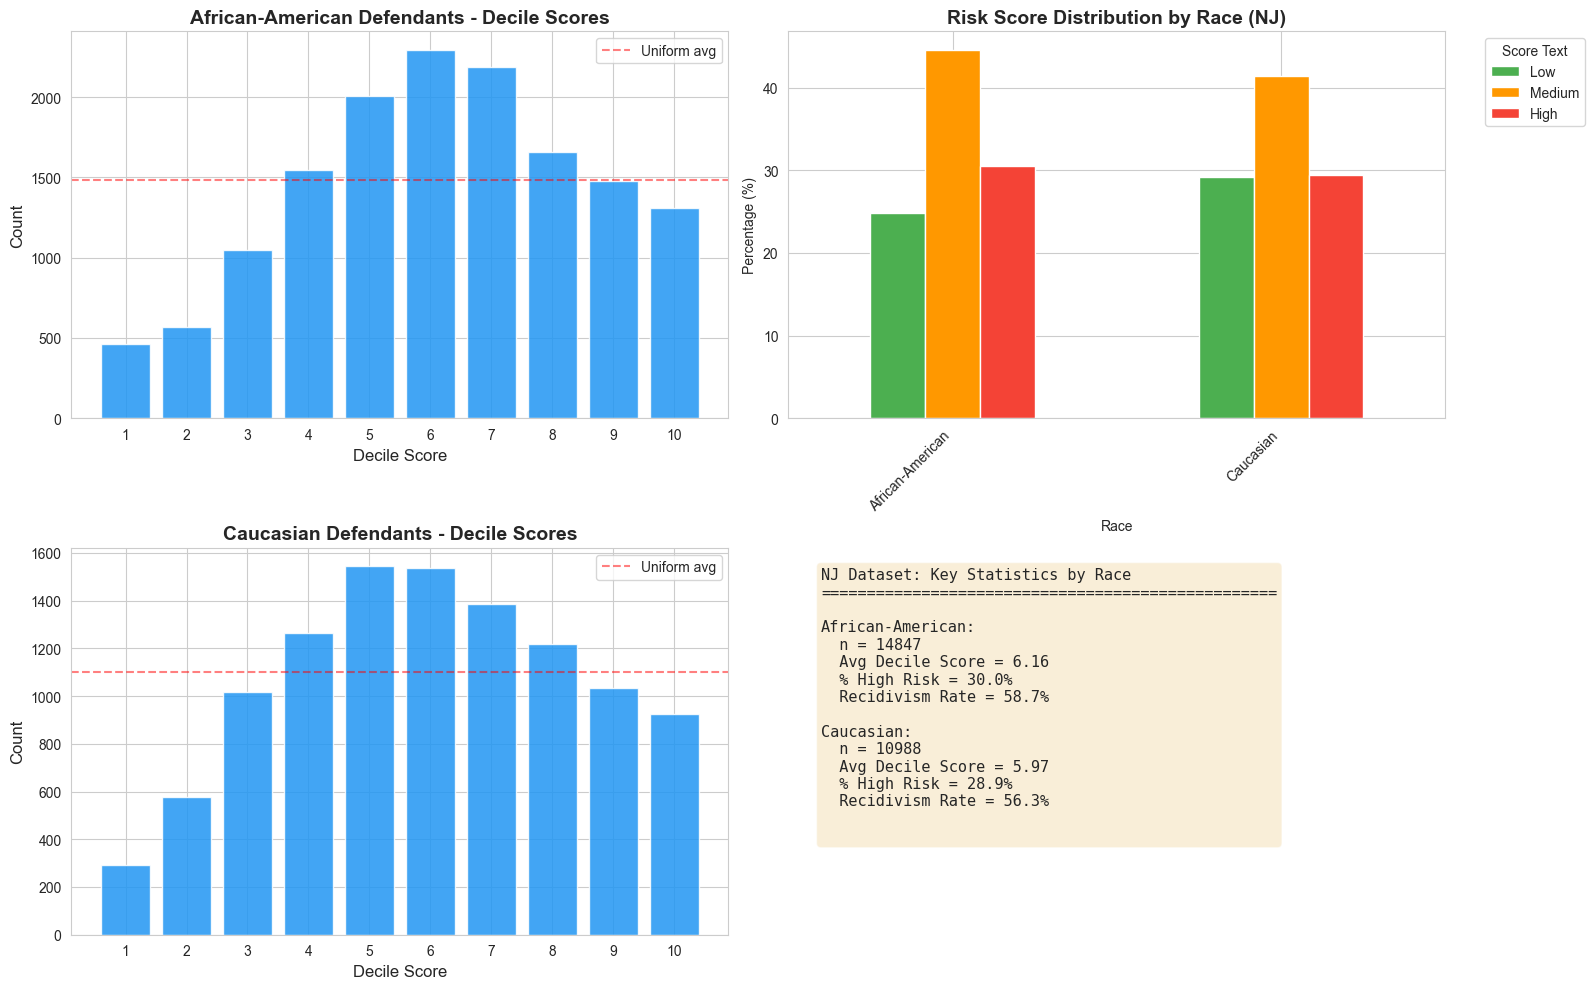


Key Observations:
  African-American with score >= 7: 6639 (44.7%)
  Caucasian with score >= 7: 4560 (41.5%)


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Get the two largest racial groups
race_counts = nj_aligned["race"].value_counts()
top_races = race_counts.head(2).index.tolist()

for idx, race in enumerate(top_races):
    race_df = nj_aligned[nj_aligned["race"] == race]
    score_counts = race_df["decile_score"].value_counts().sort_index()
    
    ax = axes[idx, 0]
    ax.bar(score_counts.index, score_counts.values, color='#2196F3', edgecolor='white', alpha=0.85)
    ax.set_xlabel("Decile Score", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(f"{race} Defendants - Decile Scores", fontsize=14, fontweight='bold')
    ax.set_xticks(range(1, 11))
    if len(score_counts) > 0:
        ax.axhline(y=len(race_df)/10, color='red', linestyle='--', alpha=0.5, label='Uniform avg')
        ax.legend()

# Score text distribution by race
score_by_race = pd.crosstab(nj_aligned["race"], nj_aligned["score_text"], normalize='index') * 100
score_by_race = score_by_race[["Low", "Medium", "High"]]

ax = axes[0, 1]
score_by_race.plot(kind='bar', ax=ax, color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='white')
ax.set_title("Risk Score Distribution by Race (NJ)", fontsize=14, fontweight='bold')
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Race")
ax.legend(title="Score Text", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Score statistics by race
ax = axes[1, 1]
ax.axis('off')

stats_text = "NJ Dataset: Key Statistics by Race\n" + "="*50 + "\n\n"
for race in nj_aligned["race"].unique():
    if pd.isna(race):
        continue
    race_df = nj_aligned[nj_aligned["race"] == race]
    if len(race_df) > 0:
        avg_score = race_df["decile_score"].mean()
        high_pct = (race_df["score_text"] == "High").mean() * 100
        recid_rate = race_df["two_year_recid"].mean() * 100
        stats_text += f"{race}:\n"
        stats_text += f"  n = {len(race_df)}\n"
        stats_text += f"  Avg Decile Score = {avg_score:.2f}\n"
        stats_text += f"  % High Risk = {high_pct:.1f}%\n"
        stats_text += f"  Recidivism Rate = {recid_rate:.1f}%\n\n"

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nKey Observations:")
for race in top_races:
    race_df = nj_aligned[nj_aligned["race"] == race]
    high_score = (race_df["decile_score"] >= 7).sum()
    high_pct = high_score / len(race_df) * 100
    print(f"  {race} with score >= 7: {high_score} ({high_pct:.1f}%)")